# LLM Workshop Code Along

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fryan2503/llm_workshop/blob/main/presentation_code_along.ipynb)

This notebook mirrors `presentation.qmd` and gives runnable demos for each section.

## Agenda

1. LLM Foundations\n
2. RAG\n
3. LLM Evals\n
4. LLM Agents\n
5. MCP and App Patterns

In [16]:
# ── Colab Setup ──────────────────────────────────────────────────────────────
# Run this cell first if you are on Google Colab

import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install -q openai tiktoken numpy pandas sentence-transformers \
        langchain-core langchain-community langchain-openai langchain-nomic \
        langgraph faiss-cpu

    # Clone repo to get data/ and vstore/ directories
    !git clone --depth 1 https://github.com/fryan2503/llm_workshop.git _repo
    import shutil, os
    for folder in ["data", "vstore"]:
        if not os.path.exists(folder):
            shutil.copytree(f"_repo/{folder}", folder)


fatal: destination path '_repo' already exists and is not an empty directory.


In [ ]:
import os
import json
import random
import sqlite3
from typing import TypedDict, Annotated, List

import tiktoken
import numpy as np
import pandas as pd
from langchain_core.messages import HumanMessage, AnyMessage
from langgraph.graph.message import add_messages
from openai import OpenAI

random.seed(42)

In [23]:
if IN_COLAB:

  embedding_api_key=userdata.get("OPENAI_API_KEY_EMBEDDINGS")

  response_api_key=userdata.get("OPENAI_API_KEY_RESPONSES")

## LLM Foundations: Tokenization

In [ ]:
enc = tiktoken.encoding_for_model("gpt-2")

sample = "NotebookLM is a RAG app for source-grounded Q&A."
tokens = enc.encode(sample)

print(tokens)
print("Token count:", len(tokens))
print("Decoded tokens:", [enc.decode([t]) for t in tokens])

[6425, 2070, 31288, 318, 257, 371, 4760, 598, 329, 2723, 12, 2833, 276, 1195, 5, 32, 13]
Token count: 17
Decoded tokens: ['Note', 'book', 'LM', ' is', ' a', ' R', 'AG', ' app', ' for', ' source', '-', 'ground', 'ed', ' Q', '&', 'A', '.']


## LLM Foundations: Vector embeddings

In [ ]:
# sentence-transformers is installed in the Colab Setup cell above
# !pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 20049.81it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
embeddings = model.encode("Miami Universoty of Ohio")
print(embeddings[:10])
print(embeddings.shape)

[ 0.02065466 -0.03984684 -0.02121316  0.0223866   0.01308369 -0.03353535
 -0.03918867 -0.0909925  -0.03492295  0.04086898]
(384,)


### Euclidean Distance

$$
d(\mathbf{a}, \mathbf{b}) = \|\mathbf{a} - \mathbf{b}\| = \sqrt{\sum_{i=1}^{n}(a_i - b_i)^2}
$$

### Cosine Similarity

$$
\text{cos}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \, \|\mathbf{b}\|} = \frac{\sum_{i=1}^{n} a_i b_i}{\sqrt{\sum_{i=1}^{n} a_i^2} \; \sqrt{\sum_{i=1}^{n} b_i^2}}
$$

### Comparison

| | Euclidean Distance | Cosine Similarity |
|---|---|---|
| **Measures** | Magnitude of separation in space | Angular similarity of direction |
| **Range** | $[0, \infty)$ | $[-1, 1]$ |
| **Identical vectors** | $0$ | $1$ |
| **Orthogonal vectors** | $\sqrt{\|\mathbf{a}\|^2 + \|\mathbf{b}\|^2}$ | $0$ |
| **Scale-invariant** | No | Yes |
| **Best for** | Clustering, k-NN | Retrieval, semantic search |



> cosine gives more spread between similar items, while Euclidean gives more spread between dissimilar items.





In [ ]:
def euclidean_distance(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))

def cosine_similarity(a, b):
    a, b = np.array(a), np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [ ]:
texts = [
    "emergency stop procedure for CNC lathe",
    "how to halt the CNC machine in an emergency",
    "the weather in Ohio today",
]

embs = model.encode(texts)

for i in range(len(texts)):
    for j in range(i + 1, len(texts)):
        print(f"\n'{texts[i]}' vs '{texts[j]}'")
        print(f"  Cosine Similarity:   {cosine_similarity(embs[i], embs[j]):.4f}")
        print(f"  Euclidean Distance:  {euclidean_distance(embs[i], embs[j]):.4f}")


'emergency stop procedure for CNC lathe' vs 'how to halt the CNC machine in an emergency'
  Cosine Similarity:   0.5908
  Euclidean Distance:  0.9047

'emergency stop procedure for CNC lathe' vs 'the weather in Ohio today'
  Cosine Similarity:   -0.0166
  Euclidean Distance:  1.4259

'how to halt the CNC machine in an emergency' vs 'the weather in Ohio today'
  Cosine Similarity:   0.0377
  Euclidean Distance:  1.3873


## LLM Foundations: `temperature`

Higher temp = more random

If your logits are [2, 1, 0.5], dividing by 0.1 gives [20, 10, 5]. Now the differences are huge, so softmax pushes almost all probability onto the top token — the distribution becomes skewed, aka the model is way more confidentt.

$$
\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

In [ ]:
logits = np.array([2.0, 1.0, 0.5])
labels = ["A", "B", "C"]

def softmax(logits):
    scaled = logits
    exp = np.exp(scaled - scaled.max())
    return np.round(exp / exp.sum(), 2)

print(softmax(logits/1.2)) # raw probabilits
print(softmax(logits/0.3)) # low temp -> more determinisitc/less random
print(softmax(logits/10)) # high temp -> less determinisitc/more random

[0.58 0.25 0.17]
[0.96 0.03 0.01]
[0.36 0.33 0.31]


# Open AI API

In [26]:
client = OpenAI(api_key = response_api_key) # this is the native openai api, the alternatice is langchain chatOpenAI
response = client.responses.create(
    model='gpt-5-mini-2025-08-07',
    input='Summarize why grounding matters in RAG in 2 bullets.',

)
print(response.output_text)

- Reduces hallucinations and improves factual accuracy: grounding responses in retrieved documents ties generated claims to verifiable source content, making answers more relevant, up-to-date, and correct for domain-specific queries.  
- Enables verifiability, accountability, and trust: grounded outputs let users check sources, attribute information, support compliance/auditing, and make model behavior easier to debug and improve.


### Embedding Example (Langchain)

In [27]:
from langchain_openai import OpenAIEmbeddings
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small", api_key = embedding_api_key) # this is openai and costs money
response = embedding_model.embed_query("Ryan Singh is awesome")
print(response[:10])

[-0.00650787353515625, 0.042755126953125, -0.0665283203125, -0.01708984375, -0.021026611328125, -0.03765869140625, 0.0244903564453125, 0.038360595703125, -0.00345611572265625, -0.03118896484375]


### Embedding Example (Native OpenAI)

In [29]:
from openai import OpenAI

client = OpenAI(api_key = embedding_api_key)

response = client.embeddings.create(
    model="text-embedding-3-small",
    input="Ryan Singh is awesome",
)

embedding = response.data[0].embedding
print(len(embedding))
print(embedding[:10])

1536
[-0.00650787353515625, 0.042755126953125, -0.0665283203125, -0.01708984375, -0.021026611328125, -0.03765869140625, 0.0244903564453125, 0.038360595703125, -0.00345611572265625, -0.03118896484375]


# Retrival Augmented Generation

I love art and this project started from a small idea of making art accessible. The problem was that RCCAM(Richard and Carole Cocks Art Museum) used a outdated SQL-based system to find artwork. When a curator goes in, they have to input exact SQL statements to find the artwork, the issue is that, the object in the system may not be tagged properly or not have all infomation in the system. My primary goal was to make a natural language retrival possible.

## Creating a vector store

In [30]:
EMBEDDINGS_DIRECTORY = './vstore'
import json
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

from langchain_nomic.embeddings import NomicEmbeddings
from langchain_openai import OpenAIEmbeddings

with open("data/extracted_data.json") as file:
    data = json.load(file)

In [32]:
# use_openai = True
# if use_openai:
#     embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
# else:
#     embedding_model = NomicEmbeddings(model="nomic-embed-text-v1.5", inference_mode="local")

# docs = []
# for art in data:
#     page_content = (
#         f"Title: {art.get('Title', 'Unknown')}\n"
#         f"Creator: {art.get('Creator', 'Unknown')}\n"
#         f"Date: {art.get('Date', 'Unknown')}\n"
#         f"Medium: {art.get('Medium', 'Unknown')}\n"
#         f"Format: {art.get('Format', 'Unknown')}\n"
#         f"Subject: {art.get('Subject', 'Unknown')}\n"
#         f"Description: {art.get('Description', 'No description provided.')}\n"
#         f"Tags: {', '.join(art.get('Tags', []))}\n"
#     )
#     metadata = {
#         "id": art.get("Identifier"),
#         "title": art.get("Title"),
#         "creator": art.get("Creator"),
#         "date": art.get("Date"),
#         "medium": art.get("Medium"),
#         "format": art.get("Format"),
#         "subject": art.get("Subject"),
#         "donor": art.get("Donor"),
#         "citation": art.get("Citation"),
#         "tags": art.get("Tags", []),
#         "collection_link": art.get("Collection Link", None),
#     }
#     docs.append(Document(page_content=page_content, metadata=metadata))

# # vectorstore = FAISS.from_documents(documents=docs, embedding=embedding_model)
# # vectorstore.save_local(EMBEDDINGS_DIRECTORY)
# # print(f"Vector store created and saved to {EMBEDDINGS_DIRECTORY}")

## Loading the Vector Store

In [33]:
vectorstore = FAISS.load_local(
  EMBEDDINGS_DIRECTORY,
  embeddings = embedding_model,
  allow_dangerous_deserialization = True
  )
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

In [34]:
docs = retriever.invoke("Paul Cadmus") # example of using retriever as a node in LangGraph
for doc in docs:
    print(doc.metadata)

{'id': '2009.13', 'title': 'The Guitarist', 'creator': 'Paul Cadmus', 'date': '1969', 'medium': None, 'format': 'Painting', 'subject': 'Modern & Contemporary-Paintings-20th C. & Later', 'donor': 'Bequest of Robert E. White, Jr.', 'citation': 'Paul Cadmus, “The Guitarist,”Richard and Carole Cocks Art Museum at Miami University, accessed July 6, 2025,https://miamiuniversityartmuseum.omeka.net/items/show/1969.', 'tags': [], 'collection_link': 'https://miamiuniversityartmuseum.omeka.net/items/show/1969'}
{'id': '2015.2.32', 'title': 'Buckle plaque with standing man and cart', 'creator': None, 'date': '200-100 BCE', 'medium': None, 'format': 'Bronze', 'subject': 'Ancient & Classical', 'donor': None, 'citation': '“Buckle plaque with standing man and cart,”Richard and Carole Cocks Art Museum at Miami University, accessed July 6, 2025,https://miamiuniversityartmuseum.omeka.net/items/show/1145.', 'tags': [], 'collection_link': 'https://miamiuniversityartmuseum.omeka.net/items/show/1145'}
{'id':

## Setting an LLM

This is what makes langchain/langgraph useful. We can easily switch out llm's very easily.

In [35]:
from langgraph.graph import START, END, StateGraph

# ── Choose your model ──────────────────────────────────────────────────────────
# Options: "openai", "ollama", "local"
MODEL_PROVIDER = "openai"

if MODEL_PROVIDER == "openai":
    from langchain_openai import ChatOpenAI
    llm = ChatOpenAI(model="gpt-5-mini-2025-08-07", api_key = response_api_key )

elif MODEL_PROVIDER == "ollama":
    from langchain_ollama import ChatOllama
    llm = ChatOllama(model="llama3", temperature=0)

else:
    from transformers import pipeline as hf_pipeline
    from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace
    pipe = hf_pipeline(
        "text-generation",
        model="Qwen/Qwen2.5-1.5B-Instruct",
        device_map="auto",
        dtype="auto",
        max_new_tokens=512,
    )
    llm = ChatHuggingFace(llm=HuggingFacePipeline(pipeline=pipe))

In [22]:
response = llm.invoke("Summarize why grounding matters in RAG in 2 bullets.")
response.content

'- Anchoring generated responses to retrieved documents reduces hallucinations and factual errors by forcing the model to base claims on evidence, improving accuracy and relevance.  \n- Providing provenance (citations and source context) enables verification, user trust, auditability, and compliance with domain constraints or up-to-date information.'

## Langgraph Runnable State

In [36]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    route: str
    documents: List[str]
    question: str
    generation: str

## Prompt Template
- This needs to be tuned

In [37]:
def retrieve(state):
    """
    Retrieve documents from vectorstore using the user question.
    """
    print("---RETRIEVE---")
    question = state["question"] # we are assessing the state dict's question
    documents = retriever.invoke(question)
    # print(f"Retrieved {len(documents)} documents")
    print(documents[0].metadata)
    return {"documents": documents}


def generate(state):
    """
    Generate an answer using the retrieved documents.
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    context = "\n".join([doc.page_content for doc in documents])
    prompt = rag_prompt.format(context=context, question=question)
    generation = llm.invoke([HumanMessage(content=prompt)])
    return {"generation": generation}

In [38]:
rag_prompt = """You are an assistant for an art museum and cultural heritage institution.
Someone has a question about the collection, and you need to answer it using the following retrieved documents as context.

Here is the context to use to answer the question:

{context}

Think carefully about the above context.

Now, review the user question:

{question}

Provide an answer to this questions using only the above context.

Use three sentences maximum and keep the answer concise.

Answer:"""

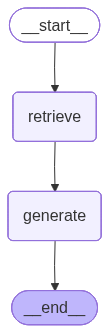

In [39]:
from IPython.display import Image, display

builder = StateGraph(State)

# Nodes
builder.add_node("retrieve", retrieve)
builder.add_node("generate", generate)

# Edges: START → retrieve → generate → END
builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "generate")
builder.add_edge("generate", END)

# Compile
graph = builder.compile()

# Visualise
display(Image(graph.get_graph().draw_mermaid_png()))

## Example Run

Let's try to look for this painting

https://miamiuniversityartmuseum.omeka.net/items/show/1969

In [40]:
question = {"question":" Are there any paul cadmus paintings in the collection?"}
response = graph.invoke(question)
print(response["generation"].content)

---RETRIEVE---
{'id': '2009.13', 'title': 'The Guitarist', 'creator': 'Paul Cadmus', 'date': '1969', 'medium': None, 'format': 'Painting', 'subject': 'Modern & Contemporary-Paintings-20th C. & Later', 'donor': 'Bequest of Robert E. White, Jr.', 'citation': 'Paul Cadmus, “The Guitarist,”Richard and Carole Cocks Art Museum at Miami University, accessed July 6, 2025,https://miamiuniversityartmuseum.omeka.net/items/show/1969.', 'tags': [], 'collection_link': 'https://miamiuniversityartmuseum.omeka.net/items/show/1969'}
---GENERATE---
Yes. The collection includes The Guitarist (1969) by Paul Cadmus, a painting depicting his model Jon Anderson seated in his underwear playing a guitar in a room.


In [41]:
question = {"question":"Are there any artworks that are about a person playing a stringed instrument"}
response = graph.invoke(question)
print(response["generation"].content)

---RETRIEVE---
{'id': '2009.13', 'title': 'The Guitarist', 'creator': 'Paul Cadmus', 'date': '1969', 'medium': None, 'format': 'Painting', 'subject': 'Modern & Contemporary-Paintings-20th C. & Later', 'donor': 'Bequest of Robert E. White, Jr.', 'citation': 'Paul Cadmus, “The Guitarist,”Richard and Carole Cocks Art Museum at Miami University, accessed July 6, 2025,https://miamiuniversityartmuseum.omeka.net/items/show/1969.', 'tags': [], 'collection_link': 'https://miamiuniversityartmuseum.omeka.net/items/show/1969'}
---GENERATE---
Yes. Examples include The Guitarist (Paul Cadmus), Violin Player (William Verplanck Birney), Lady with a Lute (Hugo Ballin, 1905), The Musician (Cellist Applauding Gershwin) (John P. Rettig), Das Volkslied (F. Rengan) showing a woman with a harp, and Spanish Gypsies (T. Martin) with a guitarist.


## SQL + Vector Hybrid Retrieval

Not every question needs semantic search. Some are better answered by exact SQL queries.

- **"How many paintings are in the collection?"** → SQL is faster and exact
- **"Art about loneliness and solitude"** → Vector captures semantic meaning

We'll build a **routing agent** that uses the LLM to classify each question and pick the right retrieval path.

## Creating an in-memory SQl server

In [42]:
# Load the same art data into an in-memory SQLite database
conn = sqlite3.connect(":memory:")
cur = conn.cursor()
cur.execute("""
    CREATE TABLE artworks (
        title TEXT, identifier TEXT, subject TEXT, description TEXT,
        creator TEXT, format TEXT, date TEXT, medium TEXT, donor TEXT
    )
""")
for art in data:
    cur.execute(
        "INSERT INTO artworks VALUES (?,?,?,?,?,?,?,?,?)",
        tuple(art.get(k) for k in
              ["Title","Identifier","Subject","Description","Creator","Format","Date","Medium","Donor"])
    )
conn.commit()
print(f"Loaded {cur.execute('SELECT COUNT(*) FROM artworks').fetchone()[0]} artworks into SQLite")

Loaded 2333 artworks into SQLite


In [43]:
# Example SQL query to find artworks by Paul Cadmus
cur.execute("SELECT title, creator, date FROM artworks WHERE creator LIKE '%Cadmus%'")
cur.fetchall()

[('The Guitarist', 'Paul Cadmus', '1969')]

### Adding a Router

We'll add a **router node** to the graph that classifies the user's question:
- If the question is about specific structured fields (creator, date, format, subject) → route to **SQL**
- If the question is about themes, moods, or visual descriptions → route to **vector search**

The LLM itself decides which path to take.

In [44]:
def route_question(state):
    """Use the LLM to classify the query as sql or vector."""
    router_prompt = """You are a router for an art museum database. Given a user question, decide the retrieval method.

    Return "sql" if the question asks for specific structured data like:
    - A specific artist/creator name
    - A specific date or time period
    - A count or list filtered by exact fields (format, subject, donor)

    Return "vector" if the question is about:
    - Themes, moods, or abstract concepts
    - Visual descriptions or artistic style
    - Anything requiring semantic understanding

    Respond with ONLY "sql" or "vector".

    Question: {question}"""
    #----#
    result = llm.invoke([HumanMessage(content=router_prompt.format(question=state["question"]))])
    route = result.content.strip().lower()
    if route not in ("sql", "vector"):
        route = "vector"  # default fallback
    print(f"---ROUTE: {route}---")
    return {"route": route}

In [45]:
def sql_retrieve(state):
    """Generate and execute a SQL query against the artworks table."""
    print("---SQL RETRIEVE---")
    sql_prompt = """You are a SQL assistant. Given a user question about an art museum collection,
write a SQLite SELECT query against this table:

artworks(title, identifier, subject, description, creator, format, date, medium, donor)

Return ONLY the SQL query, nothing else.

Question: {question}"""
    result = llm.invoke([HumanMessage(content=sql_prompt.format(question=state["question"]))])
    query = result.content.strip().strip("`").replace("sql\n", "").strip()
    print(f"SQL: {query}")
    try:
        rows = cur.execute(query).fetchall()
        cols = [desc[0] for desc in cur.description]
        docs_text = "\n".join(
            ", ".join(f"{c}: {v}" for c, v in zip(cols, row)) for row in rows[:10]
        )
    except Exception as e:
        docs_text = f"SQL error: {e}"
    print(docs_text)
    return {"documents": [Document(page_content=docs_text)]}

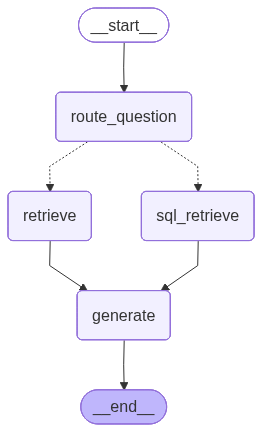

In [46]:
def decide_route(state):
    return "sql_retrieve" if state["route"] == "sql" else "retrieve"

builder = StateGraph(State)
builder.add_node("route_question", route_question)
builder.add_node("retrieve", retrieve)
builder.add_node("sql_retrieve", sql_retrieve)
builder.add_node("generate", generate)

builder.add_edge(START, "route_question")
builder.add_conditional_edges(
    "route_question",
    decide_route,
    {"sql_retrieve": "sql_retrieve", "retrieve": "retrieve"}
)
builder.add_edge("retrieve", "generate")
builder.add_edge("sql_retrieve", "generate")
builder.add_edge("generate", END)

routing_graph = builder.compile()
display(Image(routing_graph.get_graph().draw_mermaid_png()))

### Test: SQL-routed query

In [47]:
response = routing_graph.invoke({"question": "How many objects in total are in the collection?"})
print(response["generation"].content)

---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT COUNT(*) AS total FROM artworks;
total: 2333
---GENERATE---
There are 2,333 objects in total in the collection.


In [48]:
response = routing_graph.invoke({"question": "How many objects were donated by the same donor?"})
print(response["generation"].content)

---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT donor, COUNT(*) AS objects_donated
FROM artworks
GROUP BY donor
HAVING COUNT(*) > 1
ORDER BY objects_donated DESC;
donor: None, objects_donated: 845
donor: Gift of Walter I. Farmer, objects_donated: 225
donor: Gift of Ralph ('65) and Barbara Drake ('68) Bresler, objects_donated: 118
donor: Bequest of Dr. Robert E. Gregg, objects_donated: 116
donor: Gift of Edna M. Kelly, objects_donated: 81
donor: Gift of Larry Huston Family in honor of their son, Eric J. Huston, 2010, objects_donated: 51
donor: Gift of Jeffrey L. Horrell '75 and Rodney F. Rose, objects_donated: 47
donor: Gift of Charles M. Messer, objects_donated: 43
donor: Gifted by Richard and Carole Cocks, objects_donated: 42
donor: Gift of Ralph and Barbara Bresler, objects_donated: 42
---GENERATE---
Two donors each donated the same number of objects: 42. Those donors are "Gifted by Richard and Carole Cocks" and "Gift of Ralph and Barbara Bresler."


### Test: Vector-routed query

In [49]:
response = routing_graph.invoke({"question": "Art that depicts loneliness or solitude"})
print(response["generation"].content)

---ROUTE: vector---
---RETRIEVE---
{'id': '2024.18', 'title': 'Desolate', 'creator': 'Claes Oldenburg (American, b. Sweden 1929)', 'date': '1972', 'medium': 'Offset lithograph process on paper with mechanical tints', 'format': 'PrintImage Size: 9 3/4 inches x 8 inches', 'subject': 'Graphic Arts-Prints', 'donor': "Gift of Jeffrey L. Horrell '75 and Rodney F. Rose", 'citation': 'Claes Oldenburg (American, b. Sweden 1929), “Desolate,”Richard and Carole Cocks Art Museum at Miami University, accessed July 6, 2025,https://miamiuniversityartmuseum.omeka.net/items/show/20706.', 'tags': ['20th Century', 'African Oceanic and New World Cultures', 'African Oceanic and New World Cultures-North America', 'American', 'Chair', 'Claes Oldenburg', 'Couch', 'Desolate', 'European', 'Graphic Arts', 'Graphic Arts-Prints', 'Lithograph', 'Mechanical tints', 'North American', 'Paper', 'Print', 'Sofa', 'Sweden', 'United States'], 'collection_link': 'https://miamiuniversityartmuseum.omeka.net/items/show/20706'}


# LLM Evals

Evaluating RAG systems is tricky. We need to measure:
- **Accuracy**: does the model answer correctly?
- **Latency**: how fast is the response?
- **Cost**: how many tokens are we burning?

A key challenge: some questions are **deterministic** (one right answer) and some are **non-deterministic** (many valid answers). Our golden set includes both types.

In [50]:
with open("data/golden_set.json") as f:
    golden_set = json.load(f)

print(f"Golden set: {len(golden_set)} questions")
print(f"  Deterministic:     {sum(1 for q in golden_set if q['type'] == 'deterministic')}")
print(f"  Non-deterministic: {sum(1 for q in golden_set if q['type'] == 'non-deterministic')}")

print(golden_set[0])
print(golden_set[9])

Golden set: 10 questions
  Deterministic:     5
  Non-deterministic: 5
{'question': 'How many paintings are in the collection?', 'gold_answer': 'There are 644 paintings in the collection.', 'type': 'deterministic'}
{'question': 'What can you tell me about the ancient Greek and Roman artifacts?', 'gold_answer': 'The collection includes 255 ancient Greek and Roman artifacts such as vessels, cups, pyxides, and bronze objects, dating from circa 850 BCE to 300 CE.', 'type': 'non-deterministic'}


## Run RAG on the Golden Set

We run every question through our simple RAG graph and record the generated answer + latency.

In [51]:
import time

results = []
for item in golden_set:
    start = time.time()
    response = routing_graph.invoke({"question": item["question"]}) # invoke the routing graph on each question in the golden set
    elapsed = time.time() - start
    results.append({
        "question": item["question"],
        "gold_answer": item["gold_answer"],
        "type": item["type"],
        "generated_answer": response["generation"].content,
        "latency": round(elapsed, 2),
    })

results_df = pd.DataFrame(results)
results_df[["question", "type", "generated_answer", "latency"]]

---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT COUNT(*) AS painting_count FROM artworks WHERE LOWER(format) = 'painting';
painting_count: 644
---GENERATE---
---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT COUNT(*) FROM artworks WHERE creator = 'Ireland Belleek Pottery';
COUNT(*): 117
---GENERATE---
---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT medium FROM artworks WHERE creator = 'Adja Yunkers' AND title = 'Untitled III';

---GENERATE---
---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT COUNT(*) AS num_artworks FROM artworks WHERE donor = 'Walter I. Farmer';
num_artworks: 0
---GENERATE---
---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT title FROM artworks WHERE (lower(creator) LIKE '%paul cadmus%' OR lower(creator) LIKE '%cadmus%') AND (lower(format) LIKE '%paint%' OR lower(medium) LIKE '%paint%' OR lower(medium) LIKE '%oil%' OR lower(format) = 'painting');
title: The Guitarist
---GENERATE---
---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT title, identifier, subject, description, crea

,question,type,generated_answer,latency
0,How many paintings are in the collection?,deterministic,The collection contains 644 paintings.,7.06
1,How many artworks did Ireland Belleek Pottery ...,deterministic,Ireland Belleek Pottery created 117 artworks a...,6.43
2,What medium did Adja Yunkers use for 'Untitled...,deterministic,I don’t have the retrieved context or any reco...,7.76
3,How many artworks were donated by Walter I. Fa...,deterministic,"According to the provided context, Walter I. F...",6.12
4,Is there a Paul Cadmus painting in the collect...,deterministic,Yes. The Paul Cadmus painting in the collectio...,11.52
5,What artworks depict someone playing a musical...,non-deterministic,The following works depict someone playing a m...,24.87
6,Describe the African art in the collection.,non-deterministic,The collection features numerous Kuba raffia t...,7.82
7,What themes are represented in the modern and ...,non-deterministic,The paintings foreground abstraction—geometric...,6.65
8,Are there any artworks that evoke loneliness o...,non-deterministic,"Yes. Claes Oldenburg’s print ""Desolate"" (1972)...",7.30
9,What can you tell me about the ancient Greek a...,non-deterministic,The collection comprises Greek and Roman small...,10.60


## LLM as a Judge

We use a strong LLM to grade each answer on two criteria:
- **Helpfulness**: Is the answer relevant and concise to the question?
- **Correctness**: Does the answer match the gold (expected) answer factually?

For **deterministic** questions, correctness is straightforward — did it get the number right?  
For **non-deterministic** questions, this is where LLM-as-judge really earns its keep.

In [ ]:
helpfulness_prompt = """You are a teacher grading a quiz.

Given QUESTION and STUDENT ANSWER, evaluate:
1. The answer is concise and relevant to the question
2. The answer helps answer the question

QUESTION: {question}
STUDENT ANSWER: {answer}

Output "Relevance: True" if the answer is helpful and relevant, or "Relevance: False" if not.
Then explain your reasoning step-by-step."""

correctness_prompt = """You are a teacher grading a quiz.

Given QUESTION, GROUND TRUTH ANSWER, and STUDENT ANSWER, evaluate:
1. The student answer is factually accurate compared to the ground truth
2. The student answer does not contain statements that conflict with the ground truth
3. The student answer may contain more information than the ground truth, as long as it is factually accurate

QUESTION: {question}
GROUND TRUTH ANSWER: {gold_answer}
STUDENT ANSWER: {answer}

Output "Correctness: True" if the answer is factually correct, or "Correctness: False" if not.
Then explain your reasoning step-by-step."""

### Run LLM-as-Judge (Concurrent)

We call the judge LLM directly for each question — two calls per question (helpfulness + correctness), run concurrently with `asyncio`.

In [ ]:
import asyncio

async def run_judges(results):
    tasks = []
    task_labels = []
    for i, r in enumerate(results):
        h_prompt = helpfulness_prompt.format(question=r["question"], answer=r["generated_answer"])
        c_prompt = correctness_prompt.format(
            question=r["question"], gold_answer=r["gold_answer"], answer=r["generated_answer"]
        )
        tasks.append(asyncio.to_thread(judge_one_sync, client, h_prompt))
        task_labels.append((i, "helpfulness"))
        tasks.append(asyncio.to_thread(judge_one_sync, client, c_prompt))
        task_labels.append((i, "correctness"))

    responses = await asyncio.gather(*tasks)
    return list(zip(task_labels, responses))

def judge_one_sync(client, prompt_text, model="gpt-4o-mini"):
    response = client.responses.create(model=model, input=prompt_text)
    return response.output_text

start = time.time()
judge_results_raw = await run_judges(results)
print(f"Judged {len(results)} questions in {time.time() - start:.1f}s")

# Parse verdicts
for (q_idx, judge_type), text in judge_results_raw:
    first_line = text.split("\n")[0]
    if judge_type == "helpfulness":
        results[q_idx]["helpfulness"] = "True" in first_line
    else:
        results[q_idx]["correctness"] = "True" in first_line

results_df = pd.DataFrame(results)
results_df[["question", "type", "helpfulness", "correctness", "latency"]]

Judged 10 questions in 18.0s


,question,type,helpfulness,correctness,latency
0,How many paintings are in the collection?,deterministic,False,False,5.33
1,How many artworks did Ireland Belleek Pottery ...,deterministic,False,False,6.92
2,What medium did Adja Yunkers use for 'Untitled...,deterministic,True,False,5.17
3,How many artworks were donated by Walter I. Fa...,deterministic,False,False,4.76
4,Is there a Paul Cadmus painting in the collect...,deterministic,True,True,3.54
5,What artworks depict someone playing a musical...,non-deterministic,True,True,9.83
6,Describe the African art in the collection.,non-deterministic,True,False,8.89
7,What themes are represented in the modern and ...,non-deterministic,True,True,7.36
8,Are there any artworks that evoke loneliness o...,non-deterministic,True,True,7.71
9,What can you tell me about the ancient Greek a...,non-deterministic,True,False,10.57


In [ ]:
results_df = pd.DataFrame(results)
results_df[["question","generated_answer","gold_answer", "type", "helpfulness", "correctness", "latency"]]

,question,generated_answer,gold_answer,type,helpfulness,correctness,latency
0,How many paintings are in the collection?,"Based on the provided context, I can confident...",There are 644 paintings in the collection.,deterministic,False,False,5.33
1,How many artworks did Ireland Belleek Pottery ...,"I'm happy to help! However, I must point out t...",Ireland Belleek Pottery created 117 works in t...,deterministic,False,False,6.92
2,What medium did Adja Yunkers use for 'Untitled...,"According to our collection records, Adja Yunk...",Adja Yunkers used etching and screen print pro...,deterministic,True,False,5.17
3,How many artworks were donated by Walter I. Fa...,"I'm happy to help! However, based on the provi...",Walter I. Farmer donated 237 artworks to the c...,deterministic,False,False,4.76
4,Is there a Paul Cadmus painting in the collect...,"After reviewing the provided context, I found ...",Yes. 'The Guitarist' (1969) by Paul Cadmus.,deterministic,True,True,3.54
5,What artworks depict someone playing a musical...,"Based on the provided context, The Musician (C...",The collection includes 'The Guitarist' by Pau...,non-deterministic,True,True,9.83
6,Describe the African art in the collection.,The African art in our collection includes a F...,The collection includes works from various Afr...,non-deterministic,True,False,8.89
7,What themes are represented in the modern and ...,"Based on the provided context, the modern and ...",The modern and contemporary paintings cover a ...,non-deterministic,True,True,7.36
8,Are there any artworks that evoke loneliness o...,"Based on the provided context, I would recomme...",Several artworks in the collection depict soli...,non-deterministic,True,True,7.71
9,What can you tell me about the ancient Greek a...,Our collection features several ancient Greek ...,The collection includes 255 ancient Greek and ...,non-deterministic,True,False,10.57


In [ ]:
summary = results_df.groupby("type").agg(
    count=("question", "count"),
    helpfulness_rate=("helpfulness", "mean"),
    correctness_rate=("correctness", "mean"),
    avg_latency=("latency", "mean"),
).round(2)

print("=== Eval Summary by Question Type ===\n")
print(summary.to_string())
print(f"\nOverall Helpfulness: {results_df['helpfulness'].mean():.0%}")
print(f"Overall Correctness: {results_df['correctness'].mean():.0%}")
print(f"Average Latency:     {results_df['latency'].mean():.2f}s")

=== Eval Summary by Question Type ===

                   count  helpfulness_rate  correctness_rate  avg_latency
type                                                                     
deterministic          5               0.4               0.2         5.14
non-deterministic      5               1.0               0.6         8.87

Overall Helpfulness: 70%
Overall Correctness: 40%
Average Latency:     7.01s


## Alternative: Batch API (50% Cheaper)

The concurrent approach above works, but at scale (hundreds or thousands of evals) it gets expensive. The **OpenAI Batch API** is the cost-saving alternative:
- Send all requests at once as a JSONL file
- **50% discount** on token costs
- Results come back within 24 hours (usually much faster)
- Trade-off: not real-time, but perfect for nightly eval runs

In [ ]:
batch_requests = []
for i, r in enumerate(results):
    # Helpfulness judge
    batch_requests.append({
        "custom_id": f"q{i}__helpfulness",
        "method": "POST",
        "url": "/v1/responses",
        "body": {
            "model": "gpt-4o-mini",
            "input": helpfulness_prompt.format(
                question=r["question"], answer=r["generated_answer"]
            ),
        },
    })
    # Correctness judge
    batch_requests.append({
        "custom_id": f"q{i}__correctness",
        "method": "POST",
        "url": "/v1/responses",
        "body": {
            "model": "gpt-4o-mini",
            "input": correctness_prompt.format(
                question=r["question"],
                gold_answer=r["gold_answer"],
                answer=r["generated_answer"],
            ),
        },
    })

# Write JSONL
with open("data/judge_batch.jsonl", "w") as f:
    for req in batch_requests:
        f.write(json.dumps(req) + "\n")

print(f"Wrote {len(batch_requests)} judge requests to data/judge_batch.jsonl")

## Submit Batch to OpenAI

In [ ]:
# batch_file = client.files.create(
#     file=open("data/judge_batch.jsonl", "rb"),
#     purpose="batch"
# )
# batch_job = client.batches.create(
#     input_file_id=batch_file.id,
#     endpoint="/v1/responses",
#     completion_window="24h",
# )
# print(f"Batch ID: {batch_job.id}")
# print(f"Status:   {batch_job.status}")

## Check Batch Status & Download Results

Re-run this cell until status is `completed`.

In [ ]:
# batch_job = client.batches.retrieve(batch_job.id)
# print(f"Status: {batch_job.status}")

# if batch_job.status == "completed":
#     content = client.files.content(batch_job.output_file_id)
#     with open("data/judge_results.jsonl", "wb") as f:
#         f.write(content.read())
#     print("Results downloaded to data/judge_results.jsonl")

## Parse Judge Results

Extract the True/False verdicts from each judge response and build a summary table.

In [ ]:
# judge_scores = {}

# with open("data/judge_results.jsonl") as f:
#     for line in f:
#         record = json.loads(line)
#         custom_id = record["custom_id"]
#         # Extract the response text
#         output_text = record["response"]["body"]["output"][0]["content"][0]["text"]

#         q_idx, judge_type = custom_id.split("__")
#         q_num = int(q_idx.replace("q", ""))

#         if q_num not in judge_scores:
#             judge_scores[q_num] = {}

#         # Parse True/False from response
#         if judge_type == "helpfulness":
#             judge_scores[q_num]["helpfulness"] = "True" in output_text.split("\n")[0]
#         elif judge_type == "correctness":
#             judge_scores[q_num]["correctness"] = "True" in output_text.split("\n")[0]

# # Merge with results
# for i, r in enumerate(results):
#     r["helpfulness"] = judge_scores.get(i, {}).get("helpfulness", None)
#     r["correctness"] = judge_scores.get(i, {}).get("correctness", None)

# results_df = pd.DataFrame(results)
# results_df[["question", "type", "helpfulness", "correctness", "latency"]]